# Data Description Report erstellen:

In [1]:
# Data Description Report:

import pandas as pd

df = pd.read_csv("../dataset/input/BTCUSD_1d_analysis.csv")

print("🧾 Allgemeine Datenstruktur:")
display(df.info())

print("📌 Fehlende Werte:")
display(df.isnull().sum())

print("🔍 Statistische Übersicht:")
display(df.describe())

print("📅 Erste Zeilen der Daten:")
display(df.head())

🧾 Allgemeine Datenstruktur:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3805 entries, 0 to 3804
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unix        3805 non-null   int64  
 1   date        3805 non-null   object 
 2   symbol      3805 non-null   object 
 3   open        3805 non-null   float64
 4   high        3805 non-null   float64
 5   low         3805 non-null   float64
 6   close       3805 non-null   float64
 7   Volume BTC  3805 non-null   float64
 8   Volume USD  3805 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 267.7+ KB


None

📌 Fehlende Werte:


unix          0
date          0
symbol        0
open          0
high          0
low           0
close         0
Volume BTC    0
Volume USD    0
dtype: int64

🔍 Statistische Übersicht:


,unix,open,high,low,close,Volume BTC,Volume USD
count,3.805000e+03,3805.000000,3805.000000,3805.000000,3805.000000,3.805000e+03,3.805000e+03
mean,1.581466e+09,22145.493306,22668.109064,21584.042168,22170.082381,9.267225e+06,7.123671e+07
std,9.491500e+07,25132.901629,25674.762313,24558.402297,25157.408654,3.982868e+07,1.033439e+08
min,1.417133e+09,162.000000,212.840000,152.400000,162.000000,0.000000e+00,0.000000e+00
25%,1.499299e+09,2598.000000,2699.350000,2500.500000,2600.390000,2.215269e+03,1.629967e+04
50%,1.581466e+09,9969.790000,10280.710000,9606.000000,9971.000000,6.170096e+03,4.135185e+07
75%,1.663632e+09,36167.000000,37520.000000,34766.000000,36293.620000,1.772542e+06,9.561199e+07
max,1.745798e+09,106214.000000,109356.000000,105363.000000,106187.000000,7.723295e+08,1.446125e+09


📅 Erste Zeilen der Daten:


,unix,date,symbol,open,high,low,close,Volume BTC,Volume USD
0,1745798400,2025-04-28 00:00:00,BTC/USD,93780.0,93827.0,93709.0,93733.0,2.784149,2.609666e+05
1,1745712000,2025-04-27 00:00:00,BTC/USD,94662.0,95353.0,93685.0,93769.0,582.205268,5.459281e+07
2,1745625600,2025-04-26 00:00:00,BTC/USD,94720.0,95249.0,93934.0,94662.0,518.680731,4.909936e+07
3,1745539200,2025-04-25 00:00:00,BTC/USD,94010.0,95857.0,92891.0,94726.0,2287.687501,2.167035e+08
4,1745452800,2025-04-24 00:00:00,BTC/USD,93730.0,94035.0,91700.0,94010.0,1192.708175,1.121265e+08


# Datenbereinigung & Aufbereitung

In [2]:
import pandas as pd

# 1. Pfade anpassen
csv_path   = '../dataset/input/BTCUSD_1d_analysis.csv'
clean_path = '../dataset/output/btc_clean.csv'

# 2. Daten einlesen
df = pd.read_csv(csv_path)

# 3. Spaltennamen standardisieren
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

# 4. Datum parsen mit Zeitzone
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)

# 5. Duplikate und fehlende Werte entfernen
keep_cols = ['date', 'open', 'high', 'low', 'close', 'volume_usd']
df = df.drop_duplicates(subset=['date'])
df = df.dropna(subset=keep_cols)

# 6. Nur gewünschte Spalten behalten und umbenennen
df = df[keep_cols].rename(columns={
    'date': 'date_btc',
    'open': 'open_btc',
    'high': 'high_btc',
    'low':  'low_btc',
    'close':'close_btc',
    'volume_usd': 'volume_usd_btc'
})

# 7. Sortieren und Index zurücksetzen
df = df.sort_values('date_btc').reset_index(drop=True)

# 8. Speichern und Kontrolle
df.to_csv(clean_path, index=False)
print(df.head())

                   date_btc  open_btc  high_btc  low_btc  close_btc  \
0 2014-11-28 00:00:00+00:00    363.59    381.34   360.57     376.28   
1 2014-11-29 00:00:00+00:00    376.42    386.60   372.25     376.72   
2 2014-11-30 00:00:00+00:00    376.57    381.99   373.32     373.34   
3 2014-12-01 00:00:00+00:00    376.40    382.31   373.03     378.39   
4 2014-12-02 00:00:00+00:00    378.39    382.86   375.23     379.25   

   volume_usd_btc  
0         8617.15  
1         7245.19  
2         3046.33  
3         6660.56  
4         6832.53  


#  Linearen Regressionsmodell zur Vorhersage des Bitcoin-Schlusskurses

12:14:46 - cmdstanpy - INFO - Chain [1] start processing
12:14:46 - cmdstanpy - INFO - Chain [1] done processing


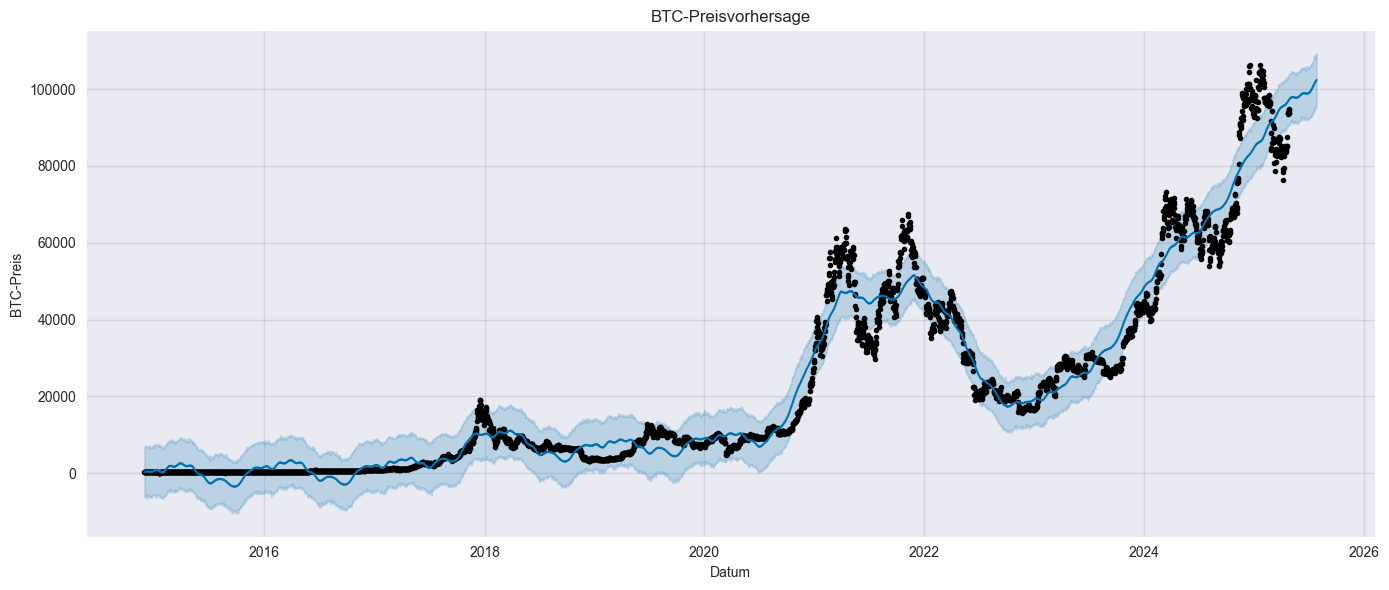

,ds,yhat,yhat_lower,yhat_upper
3805,2025-04-29,97443.998835,91176.106127,103938.312074
3806,2025-04-30,97612.364011,91197.736387,104092.350058
3807,2025-05-01,97610.439261,91324.749730,104188.414574
3808,2025-05-02,97712.259921,91071.686335,104213.955818
3809,2025-05-03,97768.042510,91408.571157,104177.281710
...,...,...,...,...
3890,2025-07-23,101916.513178,95249.543177,108454.608734
3891,2025-07-24,101972.850304,95210.988815,108785.804779
3892,2025-07-25,102138.408257,95189.379971,109148.240353
3893,2025-07-26,102263.976743,95637.142607,109283.564346


In [23]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# 📥 Daten laden
df = pd.read_csv("../dataset/output/btc_clean.csv", parse_dates=["date_btc"])

# 📥 1. Daten vorbereiten
btc_df = df[["date_btc", "close_btc"]].dropna().copy()
btc_df["date_btc"] = pd.to_datetime(btc_df["date_btc"]).dt.tz_localize(None)  # Zeitzone entfernen
btc_df.columns = ["ds", "y"]


# 📈 2. Modell initialisieren & trainieren
model = Prophet(daily_seasonality=True)
model.fit(btc_df)

# 🔮 3. Zukunftsdaten erzeugen
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# 📊 4. Visualisierung
fig = model.plot(forecast)
fig.set_size_inches(14, 6)
plt.title("BTC-Preisvorhersage")
plt.xlabel("Datum")
plt.ylabel("BTC-Preis")
plt.tight_layout()
plt.show()

# 🔍  Vorhersagewerte anzeigen
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(90)


##  Klassifikation von Marktphasen (Bull / Bear?)
###  Erkenne automatisiert, in welcher Marktphase sich BTC befindet – auf Basis technischer Indikatoren.


📊 Klassifikationsbericht:
              precision    recall  f1-score   support

        bear       0.69      0.73      0.71       152
        bull       0.79      0.86      0.82       229
    sideways       0.58      0.46      0.51       140

    accuracy                           0.71       521
   macro avg       0.69      0.68      0.68       521
weighted avg       0.70      0.71      0.71       521



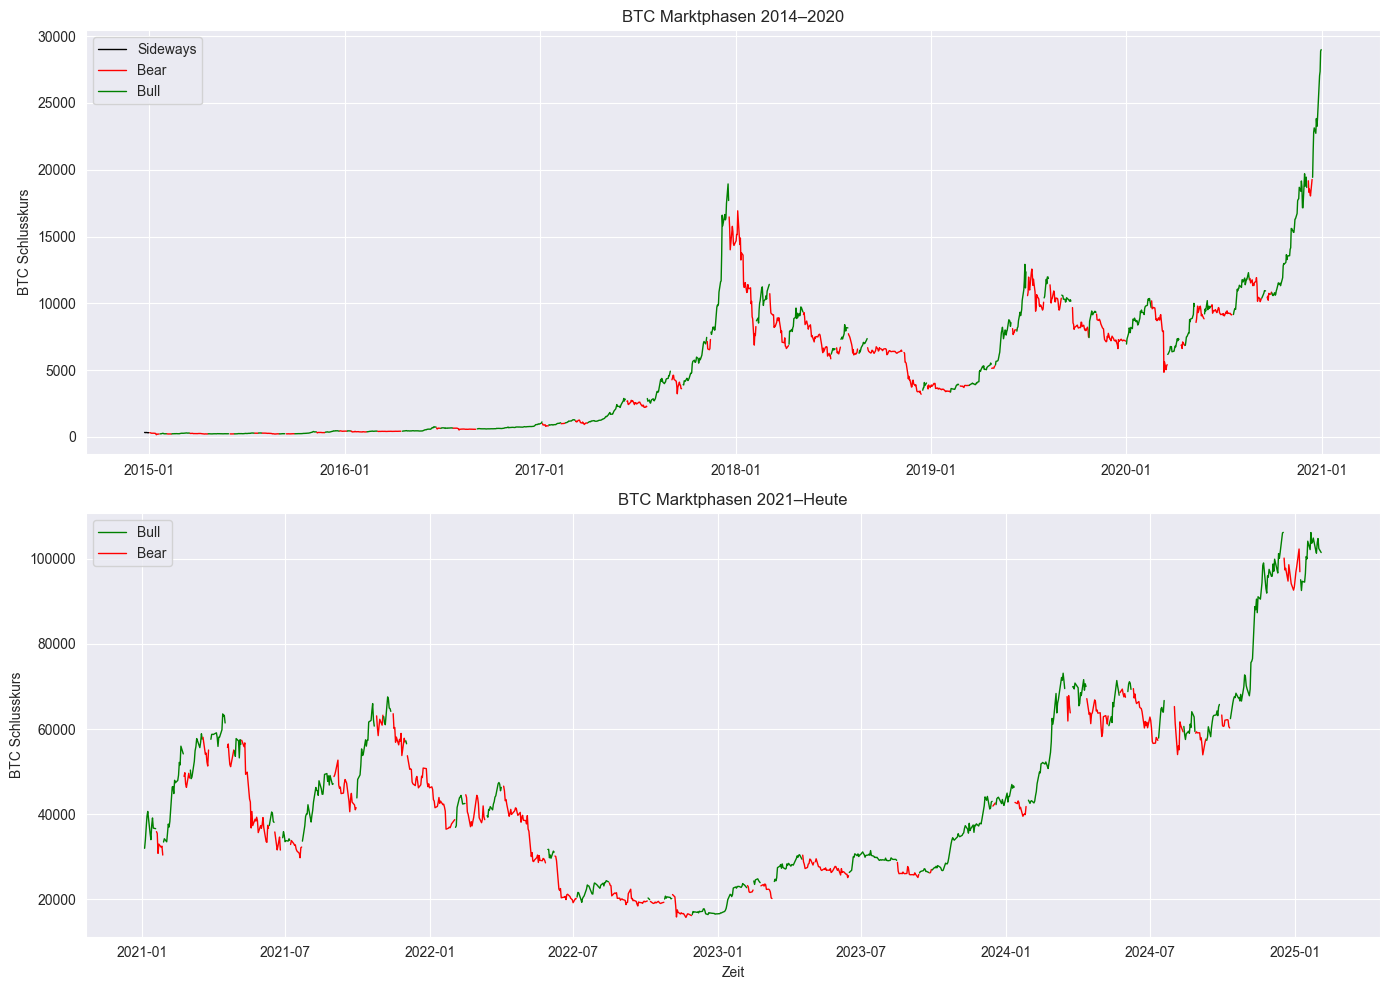

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from itertools import groupby
from operator import itemgetter

# 1️⃣ CSV laden
file_path = "../dataset/output/final_merged_technical_dataset.csv"
df = pd.read_csv(file_path, parse_dates=["timestamp"])

# 2️⃣ Zielvariable (Marktphase) aus Preisveränderung berechnen
def classify_phase(change_pct, threshold_pct=2.0):
    if change_pct > threshold_pct:
        return "bull"
    elif change_pct < -threshold_pct:
        return "bear"
    else:
        return "sideways"

# Für BTC
df["price_change_pct_btc"] = df["close_btc"].pct_change(5) * 100
df["market_phase_btc"] = df["price_change_pct_btc"].apply(lambda x: classify_phase(x))

# 3️⃣ ML-Modell vorbereiten
features = ["RSI_btc", "MACD_btc", "MA_20_btc", "Trendline_btc"]
df_model = df.dropna(subset=features + ["market_phase_btc"])
X = df_model[features]
y = df_model["market_phase_btc"]

# 4️⃣ Train/Test Split und Modelltraining
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5️⃣ Evaluation
y_pred = model.predict(X_test)
print("\n📊 Klassifikationsbericht:")
print(classification_report(y_test, y_pred))

# 6️⃣ Marktphase mit Modell vorhersagen auf dem gesamten Datensatz
df_model["predicted_phase"] = model.predict(X)

# 7️⃣ Glättung durch Rolling-Mode (Mehrheit im 7-Tage-Fenster)
def rolling_mode(series, window):
    result = []
    half_window = window // 2
    for i in range(len(series)):
        start = max(0, i - half_window)
        end = min(len(series), i + half_window + 1)
        window_vals = series[start:end]
        mode_val = pd.Series(window_vals).mode()
        result.append(mode_val[0] if not mode_val.empty else None)
    return result

df_model["smoothed_phase"] = rolling_mode(df_model["predicted_phase"].tolist(), window=7)

# 8️⃣ Minimale Segmentlänge filtern
def smooth_segments(df, phase_col="smoothed_phase", min_length=5):
    new_phases = df[phase_col].copy()
    groups = [(k, list(g)) for k, g in groupby(enumerate(df[phase_col]), key=lambda x: x[1])]
    for phase, group in groups:
        indices = list(map(itemgetter(0), group))
        if len(indices) < min_length:
            new_phase = df[phase_col].iloc[indices[0]-1] if indices[0] > 0 else phase
            new_phases.iloc[indices] = new_phase
    return new_phases

df_model["smoothed_phase"] = smooth_segments(df_model, phase_col="smoothed_phase", min_length=5)

# 🔄 Sideways an vorherige bull/bear-Phase angleichen
def replace_sideways_with_last_trend(phases):
    new_phases = phases.copy()
    last_trend = None
    for i in range(len(phases)):
        if phases[i] in ["bull", "bear"]:
            last_trend = phases[i]
        elif phases[i] == "sideways" and last_trend:
            new_phases[i] = last_trend
    return new_phases

df_model["smoothed_phase"] = replace_sideways_with_last_trend(df_model["smoothed_phase"].tolist())

# 🔀 Zwei Zeitbereiche definieren
plot_df_1 = df_model[
    (df_model["timestamp"] >= "2014-01-01") & (df_model["timestamp"] < "2021-01-01")
][["timestamp", "close_btc", "smoothed_phase"]].reset_index(drop=True)

plot_df_2 = df_model[
    df_model["timestamp"] >= "2021-01-01"
][["timestamp", "close_btc", "smoothed_phase"]].reset_index(drop=True)

# Farben definieren
phase_colors = {
    "bull": "green",
    "bear": "red"
}

# Hilfsfunktion für Segmentierung
def get_segments(df):
    segments = []
    for key, group in groupby(enumerate(df["smoothed_phase"]), key=lambda x: x[1]):
        indices = list(map(itemgetter(0), group))
        segment = df.loc[indices]
        segments.append(segment)
    return segments

segments_1 = get_segments(plot_df_1)
segments_2 = get_segments(plot_df_2)

# 📊 Zwei Subplots untereinander
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=False)

# Plot 1: 2014–2021
for segment in segments_1:
    phase = segment["smoothed_phase"].iloc[0]
    ax1.plot(
        segment["timestamp"], segment["close_btc"],
        color=phase_colors.get(phase, "black"),
        linewidth=1.0,
        label=phase.capitalize() if ax1.get_legend_handles_labels()[1].count(phase.capitalize()) == 0 else None
    )
ax1.set_title("BTC Marktphasen 2014–2020")
ax1.set_ylabel("BTC Schlusskurs")
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.legend()
ax1.grid(True)

# Plot 2: 2021–heute
for segment in segments_2:
    phase = segment["smoothed_phase"].iloc[0]
    ax2.plot(
        segment["timestamp"], segment["close_btc"],
        color=phase_colors.get(phase, "black"),
        linewidth=1.0,
        label=phase.capitalize() if ax2.get_legend_handles_labels()[1].count(phase.capitalize()) == 0 else None
    )
ax2.set_title("BTC Marktphasen 2021–Heute")
ax2.set_xlabel("Zeit")
ax2.set_ylabel("BTC Schlusskurs")
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()
